In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Real_estate_MissingValues_OutlierDetection.csv',index_col=0)
df.drop(columns=['address'],inplace=True)
df.head()

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,floorNum,agePossession,furnishing_type,additional_room_count,luxury_score
0,0,1,81,signature global city 81,0.82,8639,949,2,2,3,0.0,2.0,New,0,0.0,53
1,1,0,50,unitech nirvana birch court,11.95,36883,3240,3,3,2,"study room,servant room",3.0,Relatively Old,0,2.0,101
2,2,1,107,signature global solera,0.28,5674,493,2,2,2,0.0,11.0,New,0,0.0,29
3,3,0,5,indepedent,3.50,14787,2367,5,4,2,"pooja room,others",3.0,Old,0,2.0,36
4,4,0,3,ashok vihar phase iii extension,0.40,8889,450,7,4,3,pooja room,3.0,Relatively New,0,1.0,7


In [3]:
train_df=df.drop(columns=['Unnamed: 0','society','price_per_sqft'])
train_df.head()

,F/H,sector,price,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,floorNum,agePossession,furnishing_type,additional_room_count,luxury_score
0,1,81,0.82,949,2,2,3,0.0,2.0,New,0,0.0,53
1,0,50,11.95,3240,3,3,2,"study room,servant room",3.0,Relatively Old,0,2.0,101
2,1,107,0.28,493,2,2,2,0.0,11.0,New,0,0.0,29
3,0,5,3.50,2367,5,4,2,"pooja room,others",3.0,Old,0,2.0,36
4,0,3,0.40,450,7,4,3,pooja room,3.0,Relatively New,0,1.0,7


## FloorNum

<Axes: ylabel='floorNum'>

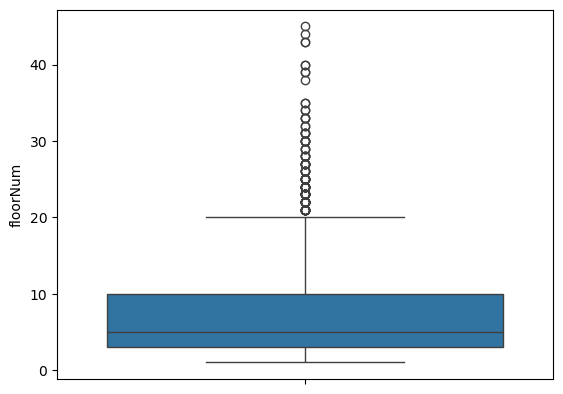

In [4]:
sns.boxplot(train_df['floorNum'])

In [5]:
train_df['floorNum'].describe()

count    3774.000000
mean        7.097244
std         5.700710
min         1.000000
25%         3.000000
50%         5.000000
75%        10.000000
max        45.000000
Name: floorNum, dtype: float64

In [6]:
def floor(row):
    if row['floorNum']<=3:
        return 'Low Floor'
    elif row['floorNum']<=10 :
        return 'Mid Floor'
    elif row['floorNum']<=45:
        return 'High Floor'
    else:
        return None

In [7]:
train_df['floorCat']=train_df.apply(floor,axis=1)

In [8]:
train_df.head()

,F/H,sector,price,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,floorNum,agePossession,furnishing_type,additional_room_count,luxury_score,floorCat
0,1,81,0.82,949,2,2,3,0.0,2.0,New,0,0.0,53,Low Floor
1,0,50,11.95,3240,3,3,2,"study room,servant room",3.0,Relatively Old,0,2.0,101,Low Floor
2,1,107,0.28,493,2,2,2,0.0,11.0,New,0,0.0,29,High Floor
3,0,5,3.50,2367,5,4,2,"pooja room,others",3.0,Old,0,2.0,36,Low Floor
4,0,3,0.40,450,7,4,3,pooja room,3.0,Relatively New,0,1.0,7,Low Floor


### Luxury Score

<Axes: ylabel='luxury_score'>

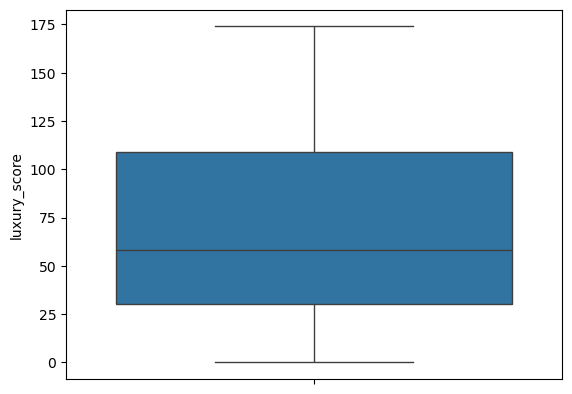

In [9]:
sns.boxplot(train_df['luxury_score'])

In [10]:
train_df['luxury_score'].describe()

count    3774.000000
mean       70.494436
std        53.002871
min         0.000000
25%        30.000000
50%        58.000000
75%       109.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

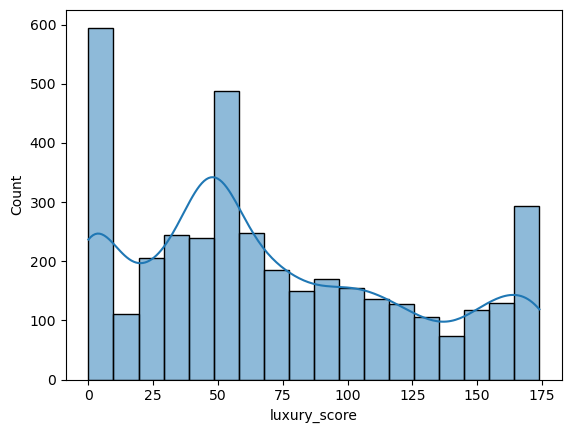

In [11]:
sns.histplot(data=train_df,x='luxury_score',kde=True)


In [12]:
def luxury_cat(row):
    if row['luxury_score']<=50:
        return 'Low'
    elif row['floorNum']<=150 :
        return 'Mid '
    elif row['floorNum']<=175:
        return 'High '
    else:
        return None

In [13]:
train_df['luxury_cat']=train_df.apply(luxury_cat,axis=1)

In [14]:
train_df.sample(2)

,F/H,sector,price,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,floorNum,agePossession,furnishing_type,additional_room_count,luxury_score,floorCat,luxury_cat
1054,1,48,4.25,4553,4,5,3,1.0,14.0,Relatively Old,2,1.0,81,High Floor,Mid
1648,1,105,0.42,750,3,2,1,1.0,7.0,Relatively Old,0,1.0,7,Mid Floor,Low


In [15]:
train_df.drop(columns=['floorNum','luxury_score','additionalRoom'],axis=1,inplace=True)

In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3774 entries, 0 to 3903
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   F/H                    3774 non-null   int64  
 1   sector                 3774 non-null   object 
 2   price                  3774 non-null   float64
 3   total_area(sqft)       3774 non-null   int64  
 4   bedRoom                3774 non-null   int64  
 5   bathroom               3774 non-null   int64  
 6   balcony                3774 non-null   int64  
 7   agePossession          3774 non-null   object 
 8   furnishing_type        3774 non-null   int64  
 9   additional_room_count  3774 non-null   float64
 10  floorCat               3774 non-null   object 
 11  luxury_cat             3774 non-null   object 
dtypes: float64(2), int64(6), object(4)
memory usage: 383.3+ KB


In [17]:
train_df['additional_room_count'].value_counts()

additional_room_count
0.0    1598
1.0    1440
2.0     426
4.0     171
3.0     139
Name: count, dtype: int64

In [18]:
train_df.columns

Index(['F/H', 'sector', 'price', 'total_area(sqft)', 'bedRoom', 'bathroom',
       'balcony', 'agePossession', 'furnishing_type', 'additional_room_count',
       'floorCat', 'luxury_cat'],
      dtype='object')

In [19]:
from sklearn.preprocessing import OrdinalEncoder
encoder_df=train_df.copy()
cat_cols=train_df.select_dtypes(include=['object']).columns

for col in cat_cols:
   oe=OrdinalEncoder() 
   encoder_df[col]=oe.fit_transform(encoder_df[[col]])
   print(oe.categories)
x_train=encoder_df.drop('price',axis=1)
y_train=encoder_df['price']

auto
auto
auto
auto


In [20]:
x_train.head()

,F/H,sector,total_area(sqft),bedRoom,bathroom,balcony,agePossession,furnishing_type,additional_room_count,floorCat,luxury_cat
0,1,99.0,949,2,2,3,0.0,0,0.0,1.0,1.0
1,0,64.0,3240,3,3,2,3.0,0,2.0,1.0,1.0
2,1,7.0,493,2,2,2,0.0,0,0.0,0.0,0.0
3,0,63.0,2367,5,4,2,1.0,0,2.0,1.0,0.0
4,0,39.0,450,7,4,3,2.0,0,1.0,1.0,0.0


In [21]:
y_train

0        0.82
1       11.95
2        0.28
3        3.50
4        0.40
        ...  
3899     5.75
3900    10.50
3901     0.60
3902     1.20
3903     2.69
Name: price, Length: 3774, dtype: float64

<Axes: >

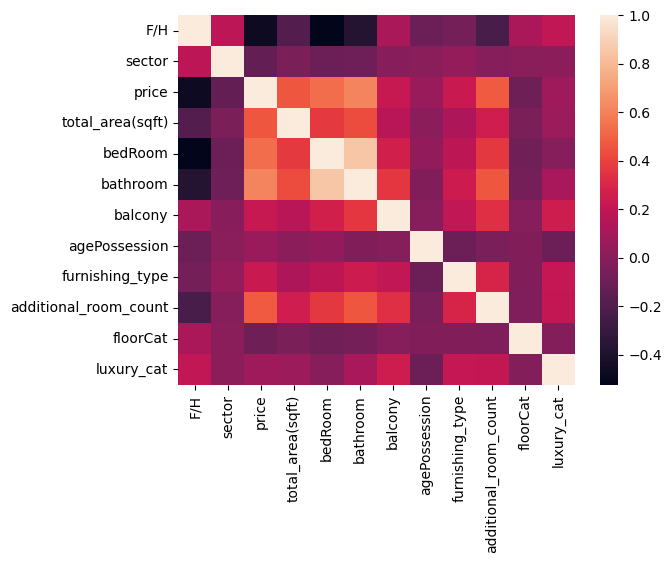

In [22]:
sns.heatmap(encoder_df.corr())

In [23]:
fi_df1 = encoder_df.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'}).sort_values(by='corr_coeff',ascending=False)
fi_df1

,feature,corr_coeff
1,price,1.000000
4,bathroom,0.612019
3,bedRoom,0.533524
8,additional_room_count,0.471564
2,total_area(sqft),0.459765
7,furnishing_type,0.226206
5,balcony,0.222343
10,luxury_cat,0.081503
6,agePossession,0.059147
9,floorCat,-0.097296


### Random Forest feature importance

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on trained  encoder data
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

# Extract feature importance scores for trained encoded data
fi_df2=pd.DataFrame({'feature':x_train.columns,
             'rf_coeff':rf.feature_importances_}).sort_values(by='rf_coeff',ascending=False)
fi_df2

,feature,rf_coeff
2,total_area(sqft),0.616851
0,F/H,0.112917
1,sector,0.101586
8,additional_room_count,0.046830
4,bathroom,0.037951
3,bedRoom,0.035965
6,agePossession,0.016086
10,luxury_cat,0.009695
7,furnishing_type,0.009445
5,balcony,0.009376


### Gradient Boosting feature importance

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on trained  encoder data
gb = GradientBoostingRegressor()
gb.fit(x_train, y_train)

# Extract feature importance scores for trained encoded data
fi_df3 = pd.DataFrame({
    'feature': x_train.columns,
    'gb_importance': gb.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3


,feature,gb_importance
2,total_area(sqft),0.637893
0,F/H,0.110307
1,sector,0.104361
4,bathroom,0.066672
8,additional_room_count,0.048859
3,bedRoom,0.022181
7,furnishing_type,0.004321
6,agePossession,0.003232
10,luxury_cat,0.001478
5,balcony,0.000530


In [26]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').set_index('feature')
final_fi_df

,corr_coeff,rf_coeff,gb_importance
feature,,,
bathroom,0.612019,0.037951,0.066672
bedRoom,0.533524,0.035965,0.022181
additional_room_count,0.471564,0.046830,0.048859
total_area(sqft),0.459765,0.616851,0.637893
furnishing_type,0.226206,0.009445,0.004321
balcony,0.222343,0.009376,0.000530
luxury_cat,0.081503,0.009695,0.001478
agePossession,0.059147,0.016086,0.003232
floorCat,-0.097296,0.003298,0.000166


In [27]:
# To normalize 
final_fi_df=final_fi_df.divide(final_fi_df.sum(axis=0),axis=1)
final_fi_df

,corr_coeff,rf_coeff,gb_importance
feature,,,
bathroom,0.251232,0.042782,0.074938
bedRoom,0.219010,0.040543,0.024931
additional_room_count,0.193575,0.052791,0.054917
total_area(sqft),0.188732,0.695370,0.716981
furnishing_type,0.092857,0.010647,0.004857
balcony,0.091271,0.010570,0.000596
luxury_cat,0.033457,0.010929,0.001661
agePossession,0.024280,0.018133,0.003633
floorCat,-0.039940,0.003718,0.000186


In [28]:
final_fi_df['mean_score']=final_fi_df[['corr_coeff','rf_coeff','gb_importance']].mean(axis=1)
final_fi_df.sort_values(by='mean_score',ascending=False)

,corr_coeff,rf_coeff,gb_importance,mean_score
feature,,,,
total_area(sqft),0.188732,0.695370,0.716981,0.533694
bathroom,0.251232,0.042782,0.074938,0.122984
additional_room_count,0.193575,0.052791,0.054917,0.100428
bedRoom,0.219010,0.040543,0.024931,0.094828
sector,-0.054473,0.114517,0.117300,0.059115
furnishing_type,0.092857,0.010647,0.004857,0.036120
balcony,0.091271,0.010570,0.000596,0.034146
luxury_cat,0.033457,0.010929,0.001661,0.015349
agePossession,0.024280,0.018133,0.003633,0.015349


In [29]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf,x_train, y_train, cv=5, scoring='r2')

In [30]:
scores.mean()

0.7848980287642258

In [31]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf,x_train.drop(columns=['floorCat']), y_train, cv=5, scoring='r2')

In [32]:
scores.mean()

0.7850757668938467

### we are gonna remove FloorCat ,AgePossession ,LuxuryCat

#### Export

In [33]:
export_df=x_train.drop(columns=['floorCat'])
export_df['price']=y_train

In [34]:
export_df

,F/H,sector,total_area(sqft),bedRoom,bathroom,balcony,agePossession,furnishing_type,additional_room_count,luxury_cat,price
0,1,99.0,949,2,2,3,0.0,0,0.0,1.0,0.82
1,0,64.0,3240,3,3,2,3.0,0,2.0,1.0,11.95
2,1,7.0,493,2,2,2,0.0,0,0.0,0.0,0.28
3,0,63.0,2367,5,4,2,1.0,0,2.0,0.0,3.50
4,0,39.0,450,7,4,3,2.0,0,1.0,0.0,0.40
...,...,...,...,...,...,...,...,...,...,...,...
3899,0,57.0,1935,4,4,2,1.0,0,3.0,0.0,5.75
3900,0,8.0,7331,5,4,3,0.0,0,0.0,1.0,10.50
3901,1,53.0,900,2,2,1,1.0,0,0.0,0.0,0.60
3902,1,111.0,1930,3,3,3,0.0,0,0.0,0.0,1.20


In [35]:
export_df.to_csv('Real_estate_featureSelection_v1.csv',index=False)

In [38]:
train_df=train_df.drop(columns=['floorCat'])
train_df.to_csv('Real_estate_featureSelection_v2.csv',index=False)